(-5.0, 105.0)

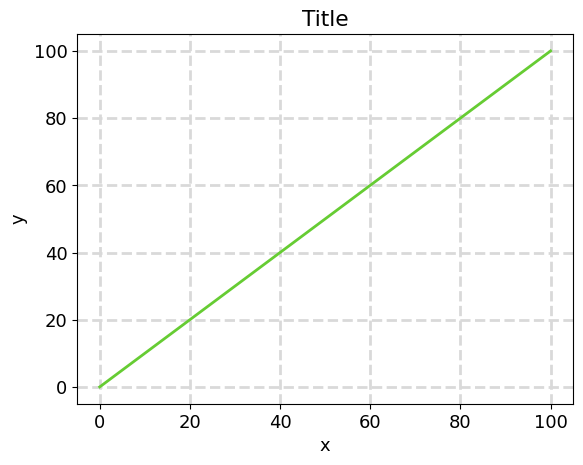

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
matplotlib.rcParams.update({'font.size': 13})
matplotlib.rcParams['lines.linewidth'] = 2

light_green = (0.4, 0.8, 0.2)
dark_purple = (0.4, 0.3, 0.7)
raspberry_pink = (1, 0, 0.5)

x = np.linspace(0, 100, 100)
y = x
plt.title("Title")
plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2)
plt.plot(x, y, color = light_green)
plt.xlabel("x")
plt.ylabel("y")
plt.ylim()
plt.xlim()

In [2]:
data1 = pd.read_excel("данные.xlsx", sheet_name="кольца")
data1

,m,"r_min, cm","r_max, cm","delta r, cm"
0,1,2.45,3.05,0.10
1,2,3.70,4.10,0.20
2,3,4.60,5.00,0.10
3,4,5.30,5.60,0.05
4,5,6.00,6.10,0.05
5,6,6.60,6.70,0.05
6,7,7.20,7.40,0.05
7,8,7.70,7.80,0.05
8,9,8.30,8.30,0.05


In [3]:
data1["r_avg^2, cm^2"] = ((data1["r_max, cm"] + data1["delta r, cm"])**2 + (data1["r_max, cm"] - data1["delta r, cm"])**2)/2
data1["r^2_sigma, cm^2"] = ((data1["r_max, cm"] + data1["delta r, cm"])**2 - (data1["r_max, cm"] - data1["delta r, cm"])**2)/2
data1

,m,"r_min, cm","r_max, cm","delta r, cm","r_avg^2, cm^2","r^2_sigma, cm^2"
0,1,2.45,3.05,0.10,9.3125,0.61
1,2,3.70,4.10,0.20,16.8500,1.64
2,3,4.60,5.00,0.10,25.0100,1.00
3,4,5.30,5.60,0.05,31.3625,0.56
4,5,6.00,6.10,0.05,37.2125,0.61
5,6,6.60,6.70,0.05,44.8925,0.67
6,7,7.20,7.40,0.05,54.7625,0.74
7,8,7.70,7.80,0.05,60.8425,0.78
8,9,8.30,8.30,0.05,68.8925,0.83


In [10]:
k = np.sum(data1["r_avg^2, cm^2"] * data1["m"]) / np.sum(data1["m"]**2)
m_th = np.linspace(1, 9, 2)
k

7.680771929824563

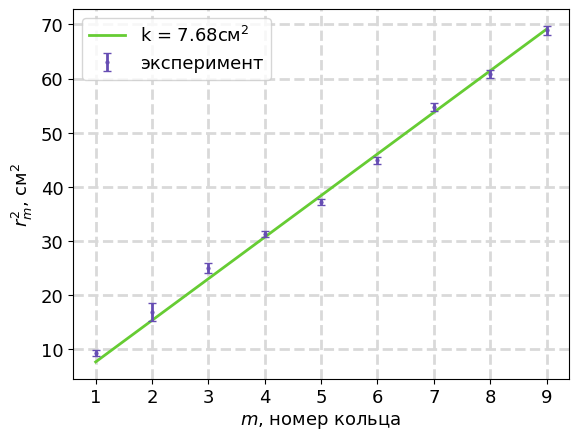

In [5]:
plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2)

plt.plot(m_th, k * m_th, color = light_green, label = f"k = {k:.2f}" + r'$\text{см}^2$')
plt.errorbar(data1["m"], data1["r_avg^2, cm^2"], 
             yerr = data1["r^2_sigma, cm^2"], 
             fmt = 'o', 
             capsize=3, 
             markersize = 2, 
             label = 'эксперимент',
             color = dark_purple)
plt.ylabel(r'$r_m^2$, $\text{см}^2$')
plt.xlabel(r'$m$, номер кольца')
plt.legend()
plt.savefig('images/rings.png', dpi = 300)

In [19]:
l = 2.6 #cm
lambda_0 = 0.63 * 1e-4 #cm 
n_0 = 2.29
L_0 = 79 #cm
L = L_0 - l/2
sigma_L = 1
delta_n = lambda_0 * n_0**2 * L**2/l/k
sigma_delta_n = ((2 * sigma_L/L)**2  + (4/76)**2)**0.5 * delta_n
delta_n, sigma_delta_n

(0.09987926419128107, 0.0058517930579496495)

71.67914469953178